# DS675 Mini-Project: Diabetes Health Indicators
## Complementary Analysis — SHAP Feature Importance




## 0. Setup — Kaggle API + Install Dependencies

In [4]:
# Upload your kaggle.json API key when prompted
from google.colab import files
files.upload()  # upload kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"techynik","key":"ac2e01769c86df04d2e70ac6286177fd"}'}

In [5]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

!kaggle datasets download -d alexteboul/diabetes-health-indicators-dataset --unzip -p ./data
!ls ./data

Dataset URL: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset
License(s): CC0-1.0
100% 6.03M/6.03M [00:00<00:00, 8.40MB/s]

diabetes_012_health_indicators_BRFSS2015.csv
diabetes_binary_5050split_health_indicators_BRFSS2015.csv
diabetes_binary_health_indicators_BRFSS2015.csv


In [6]:
!pip install shap xgboost --quiet

## 1. Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

import warnings
warnings.filterwarnings('ignore')
shap.initjs()

## 2. Load Data

In [8]:
df = pd.read_csv('./data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
print('Shape:', df.shape)
print('Target distribution:')
print(df['Diabetes_binary'].value_counts())

Shape: (70692, 22)
Target distribution:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


## 3. Data Preparation (Matches Rui's Notebook)

In [9]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# Same split as Rui
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (56553, 21) | Test: (14139, 21)


## 4. Train XGBoost Model

In [10]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train_scaled, y_train)

y_pred = xgb.predict(X_test_scaled)
y_prob = xgb.predict_proba(X_test_scaled)[:, 1]

print('=== XGBoost Performance ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

=== XGBoost Performance ===
Accuracy:  0.7539
F1 Score:  0.7647
AUC-ROC:   0.8301

              precision    recall  f1-score   support

 No Diabetes       0.78      0.71      0.74      7070
    Diabetes       0.73      0.80      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.76      0.75      0.75     14139
weighted avg       0.76      0.75      0.75     14139



## 5. SHAP Analysis

### 5.1 Compute SHAP Values

In [11]:
explainer = shap.TreeExplainer(xgb)

# Use a sample for speed (2000 rows is enough for stable SHAP estimates)
X_sample = X_test_scaled.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print('SHAP values shape:', shap_values.shape)

SHAP values shape: (2000, 21)


### 5.2 Summary Plot (Global Feature Importance)

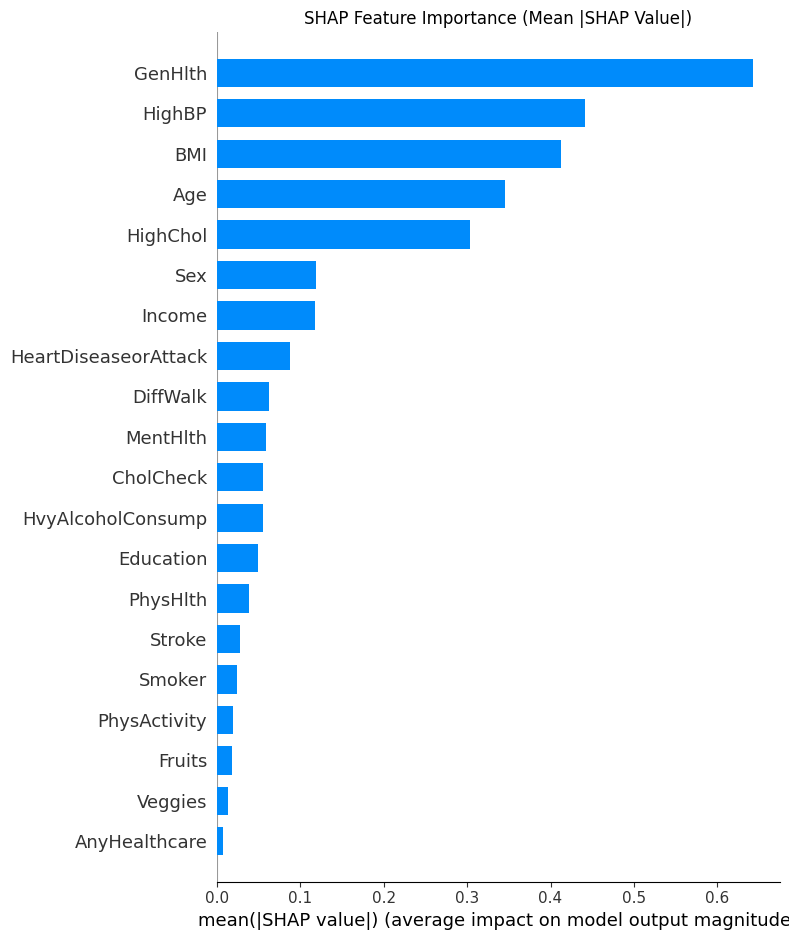

In [12]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Beeswarm Plot (Importance + Direction)

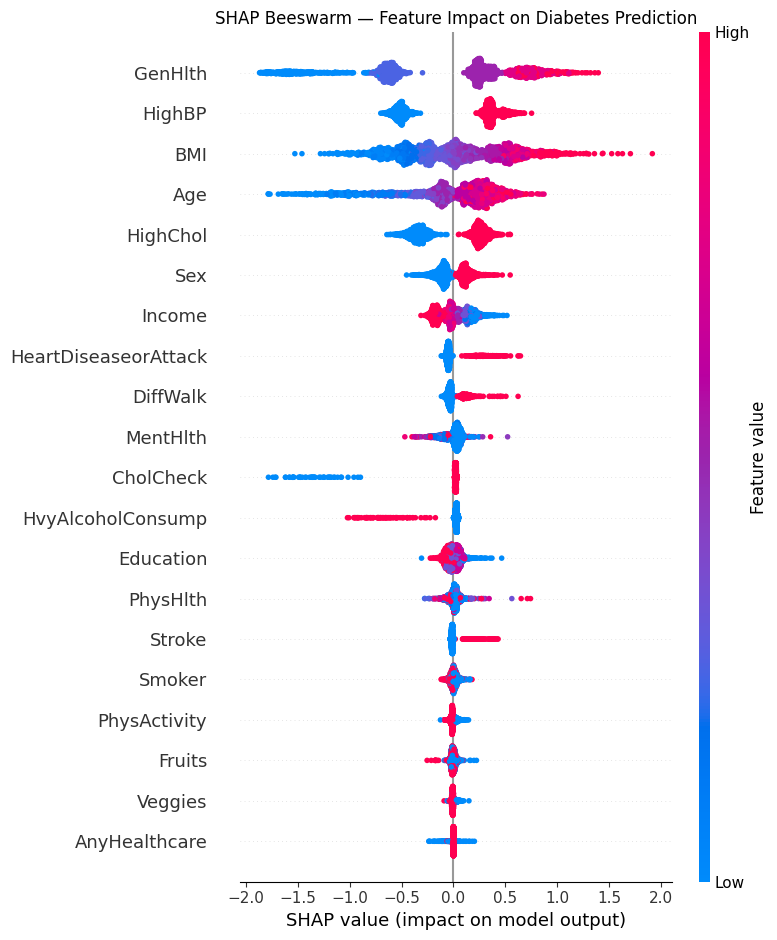

In [13]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Diabetes Prediction')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Dependence Plots — Top Features

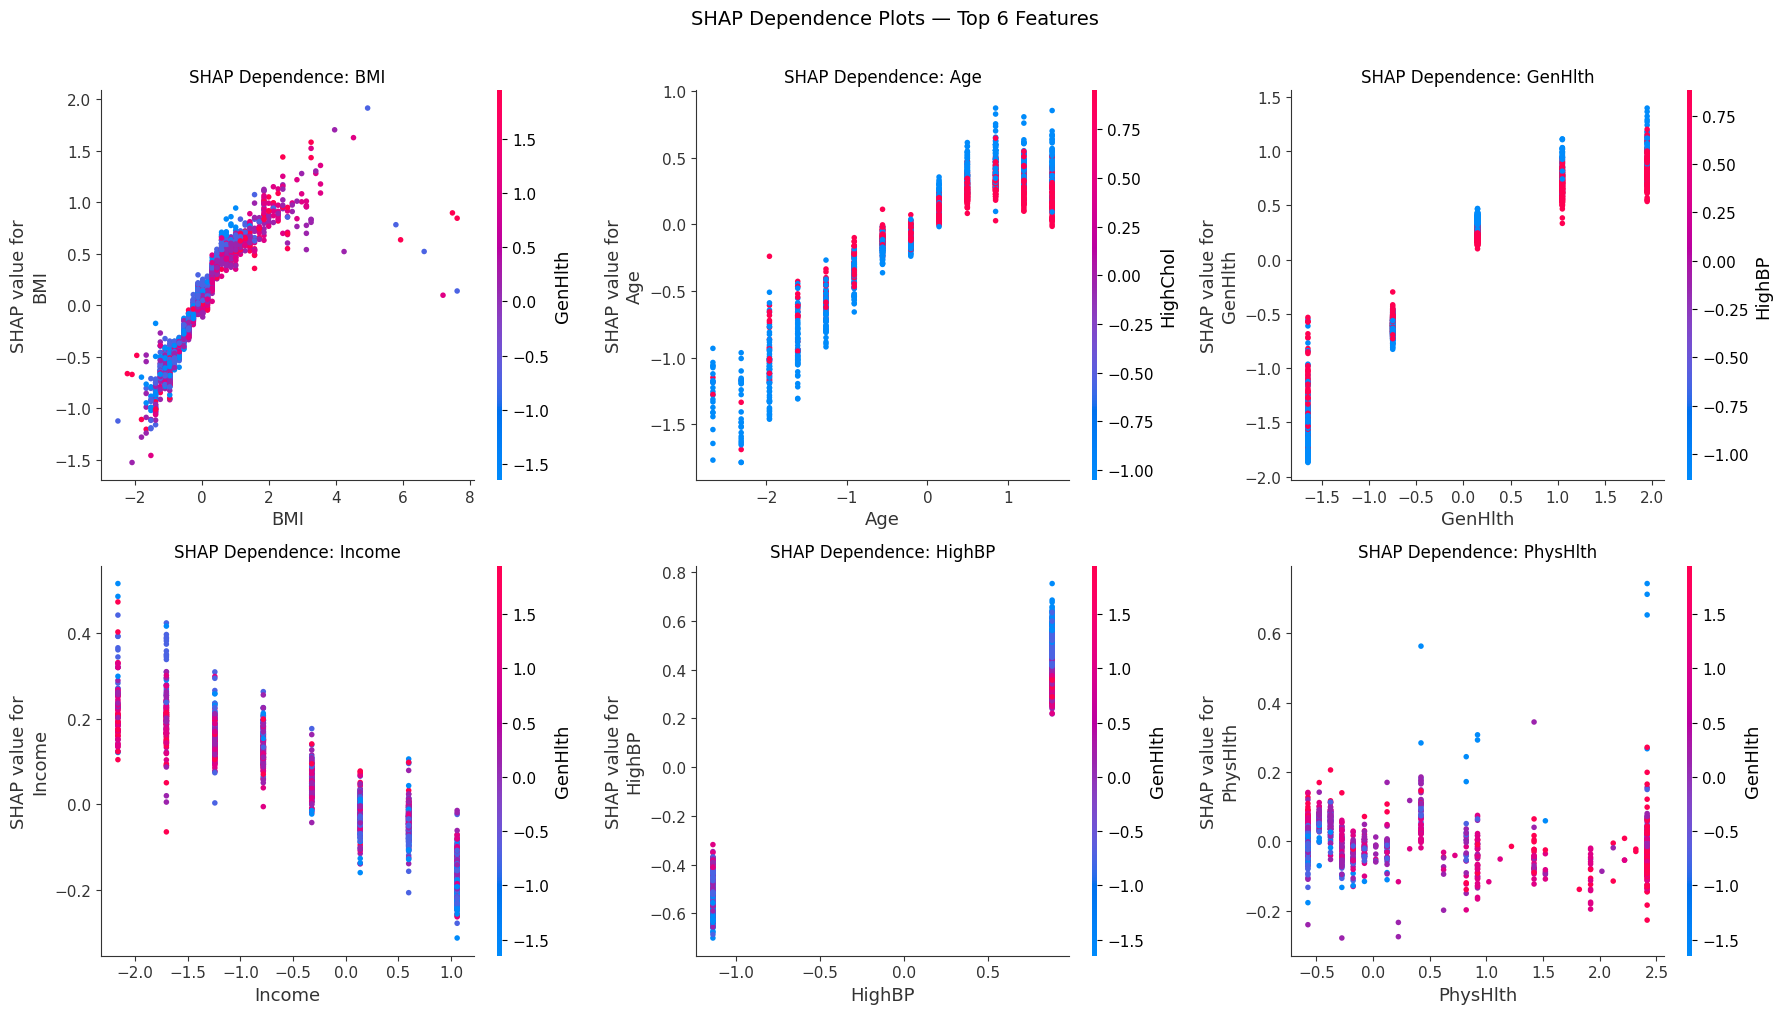

In [14]:
# Top features from Rui's RF ranking (our shared baseline)
top_features = ['BMI', 'Age', 'GenHlth', 'Income', 'HighBP', 'PhysHlth']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    shap.dependence_plot(
        feature,
        shap_values,
        X_sample,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feature}')

plt.suptitle('SHAP Dependence Plots — Top 6 Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('shap_dependence_top6.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 SHAP vs RF Importance — Comparison

In [15]:
# Mean absolute SHAP values per feature
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)

print('SHAP Feature Importance (Top 10):')
print(shap_importance.head(10).round(4))

# Rui's RF importance for reference
rf_importance = pd.Series({
    'BMI': 0.1723, 'Age': 0.1263, 'GenHlth': 0.1080,
    'Income': 0.0838, 'HighBP': 0.0740, 'PhysHlth': 0.0684,
    'Education': 0.0583, 'MentHlth': 0.0510, 'HighChol': 0.0412,
    'Fruits': 0.0282
})

# Side-by-side comparison for top 10
top10_shap = shap_importance.head(10)
comparison = pd.DataFrame({
    'SHAP Rank': range(1, 11),
    'SHAP Importance': top10_shap.values.round(4),
    'RF Rank': [list(rf_importance.index).index(f) + 1 if f in rf_importance.index else 'N/A'
                for f in top10_shap.index]
}, index=top10_shap.index)

print('\nSHAP vs RF Rank Comparison:')
print(comparison.to_string())

SHAP Feature Importance (Top 10):
GenHlth                 0.6431
HighBP                  0.4418
BMI                     0.4131
Age                     0.3460
HighChol                0.3029
Sex                     0.1186
Income                  0.1180
HeartDiseaseorAttack    0.0875
DiffWalk                0.0622
MentHlth                0.0592
dtype: float32

SHAP vs RF Rank Comparison:
                      SHAP Rank  SHAP Importance RF Rank
GenHlth                       1           0.6431       3
HighBP                        2           0.4418       5
BMI                           3           0.4131       1
Age                           4           0.3460       2
HighChol                      5           0.3029       9
Sex                           6           0.1186     N/A
Income                        7           0.1180       4
HeartDiseaseorAttack          8           0.0875     N/A
DiffWalk                      9           0.0622     N/A
MentHlth                     10           

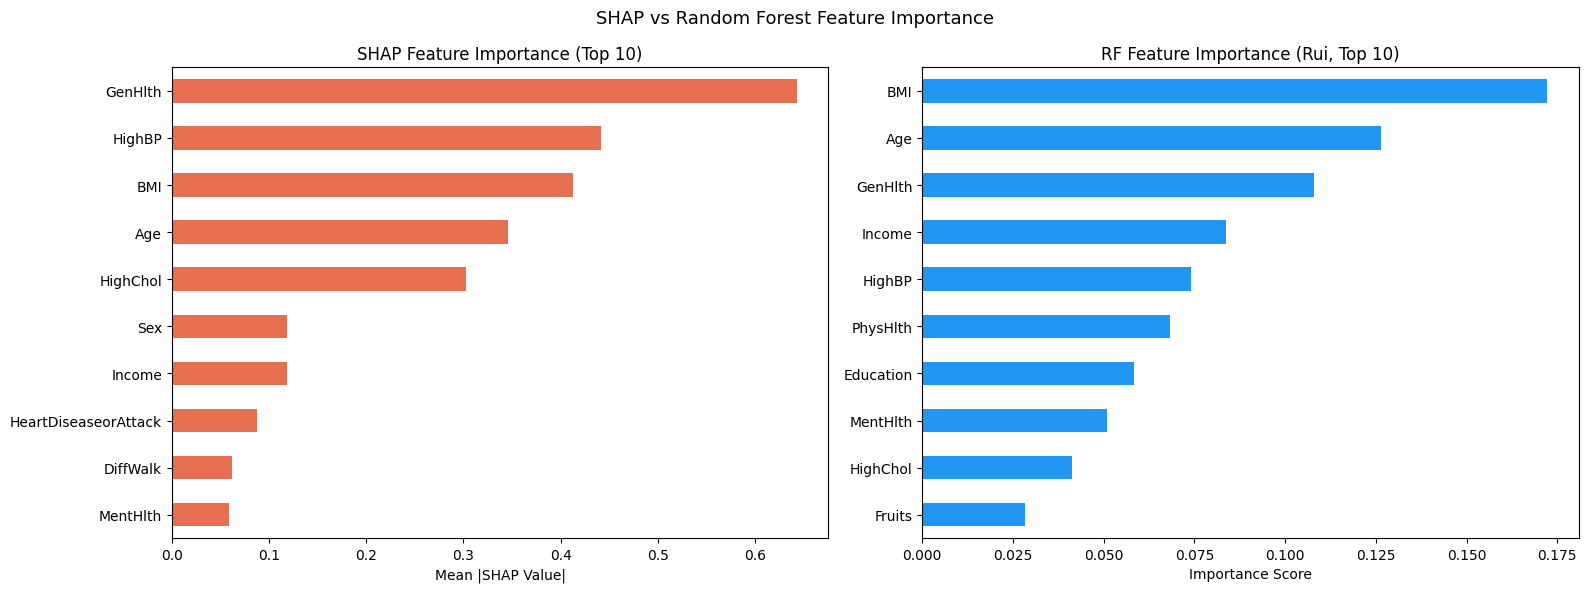

In [16]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

shap_importance.head(10).sort_values().plot(
    kind='barh', ax=axes[0], color='#E76F51'
)
axes[0].set_title('SHAP Feature Importance (Top 10)')
axes[0].set_xlabel('Mean |SHAP Value|')

rf_importance.sort_values().plot(
    kind='barh', ax=axes[1], color='#2196F3'
)
axes[1].set_title('RF Feature Importance (Rui, Top 10)')
axes[1].set_xlabel('Importance Score')

plt.suptitle('SHAP vs Random Forest Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig('shap_vs_rf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Individual Prediction Explanation (Waterfall Plot)

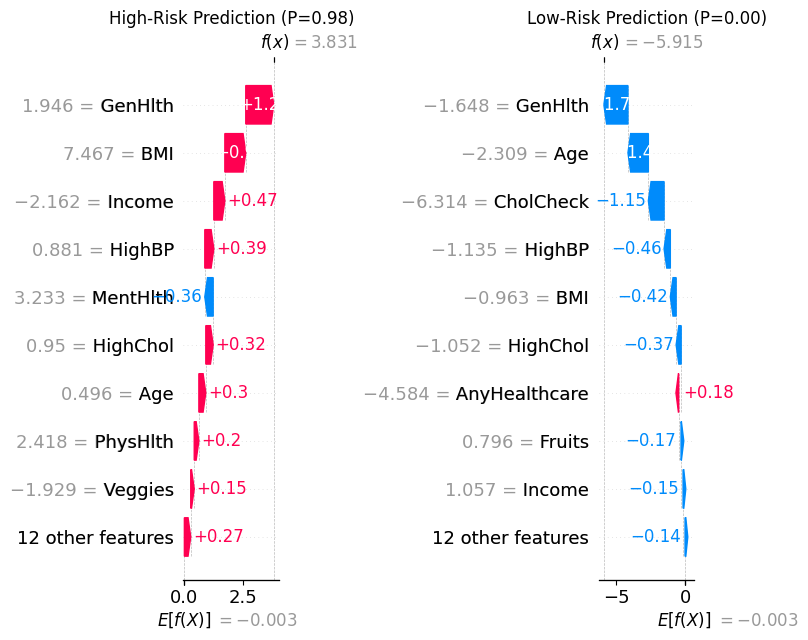

In [17]:
# Explain one high-risk prediction and one low-risk prediction
shap_exp = explainer(X_sample)

# Find a high-risk and low-risk sample
probs = xgb.predict_proba(X_sample)[:, 1]
high_risk_idx = np.argmax(probs)
low_risk_idx = np.argmin(probs)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plt.sca(axes[0])
shap.plots.waterfall(shap_exp[high_risk_idx], show=False)
axes[0].set_title(f'High-Risk Prediction (P={probs[high_risk_idx]:.2f})')

plt.sca(axes[1])
shap.plots.waterfall(shap_exp[low_risk_idx], show=False)
axes[1].set_title(f'Low-Risk Prediction (P={probs[low_risk_idx]:.2f})')

plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Key Findings

**SHAP vs RF Importance:**
- Both methods agree on the core trio (BMI, Age, GenHlth appear in both top 5s), but SHAP ranks **GenHlth #1** by a large margin while RF puts BMI #1 — SHAP is more reliable here as RF splits importance across correlated features
- **HighChol jumps from RF rank #9 to SHAP rank #5** — RF was significantly undervaluing it
- Sex, HeartDiseaseorAttack, DiffWalk don't appear in RF's top 10 but SHAP surfaces them as meaningful contributors

**Notable directional insights from beeswarm:**
- **GenHlth**: poor self-reported health (high score) → strongest positive SHAP push toward diabetes risk, largest magnitude of any feature
- **BMI**: non-linear relationship — risk rises steeply up to ~BMI 30 (scaled), then plateaus; not a simple linear effect
- **Income**: high income → negative SHAP (protective); lower income consistently increases predicted risk
- **HvyAlcoholConsump**: counterintuitive — heavy drinkers show slightly lower predicted risk; worth flagging as a potential confound in the data
- **HighBP = 1**: clear positive SHAP contribution, clinically expected

**Implication for shared feature selection:**
- SHAP suggests a slight revision to Rui's RF-based top 6 — swap **PhysHlth out, HighChol in**, giving: **GenHlth, HighBP, BMI, Age, HighChol, Income**
- XGBoost with all 21 features: AUC = 0.8301, F1 = 0.7647 — improvement over LR baseline (AUC = 0.8232, F1 = 0.7503), strengthening the case for more expressive models

## 7. Summary

| What | Detail |
|------|--------|
| Model | XGBoost (200 trees, depth=5) |
| Dataset | 50/50 balanced, 70,692 rows |
| Split | 80/20, random_state=42 (matches Rui) |
| SHAP method | TreeExplainer, 2000-sample subset |
| Key output | Feature importance + directionality + individual explanations |

## 8. SHAP on Unbalanced Binary Dataset

Running the same SHAP pipeline on the unbalanced dataset to compare feature rankings.
Note: Higher accuracy on the unbalanced set is expected — the majority class (no diabetes ~86%) inflates accuracy. F1 and AUC are the metrics that matter here.

In [18]:
df_unbal = pd.read_csv('./data/diabetes_binary_health_indicators_BRFSS2015.csv')
print('Shape:', df_unbal.shape)
print('Target distribution:')
print(df_unbal['Diabetes_binary'].value_counts())
print('Class ratio:', df_unbal['Diabetes_binary'].value_counts(normalize=True).round(3).to_dict())

Shape: (253680, 22)
Target distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
Class ratio: {0.0: 0.861, 1.0: 0.139}


=== XGBoost on Unbalanced Dataset ===
Accuracy:  0.8656
F1 Score:  0.2537
AUC-ROC:   0.8273

              precision    recall  f1-score   support

 No Diabetes       0.88      0.98      0.93     43667
    Diabetes       0.56      0.16      0.25      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736



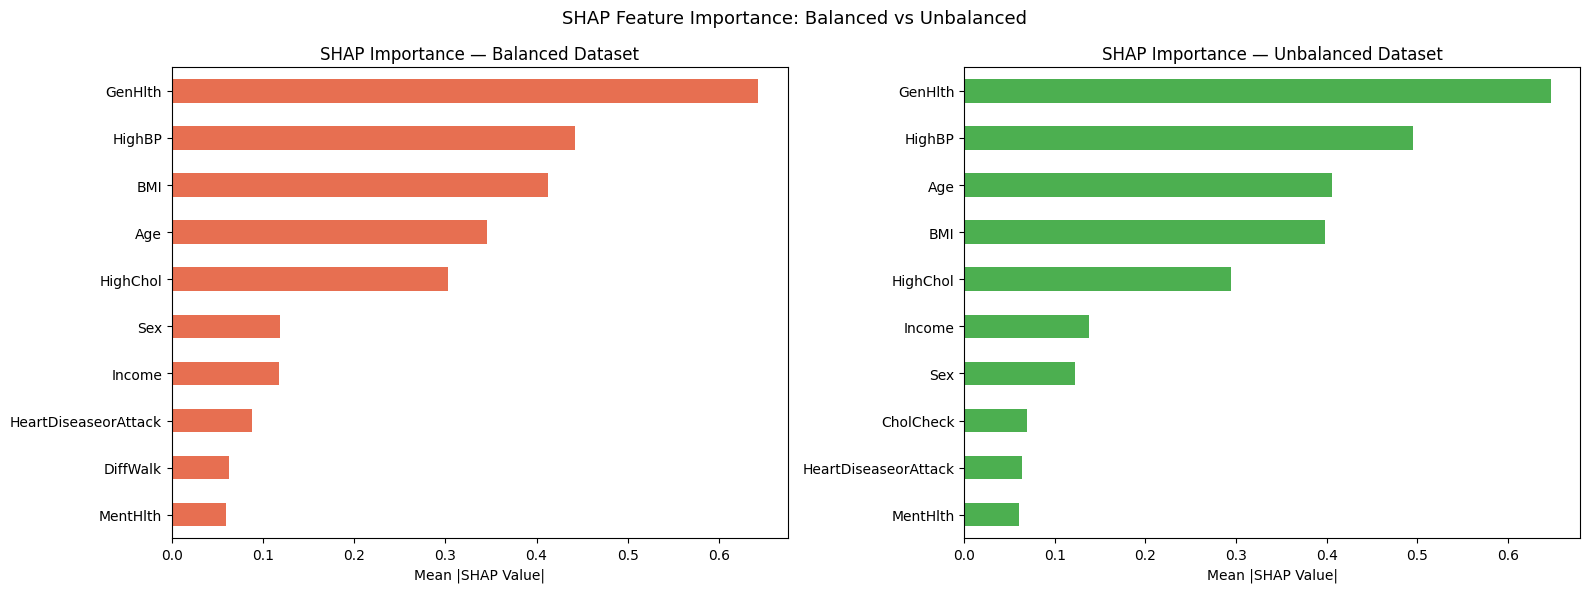

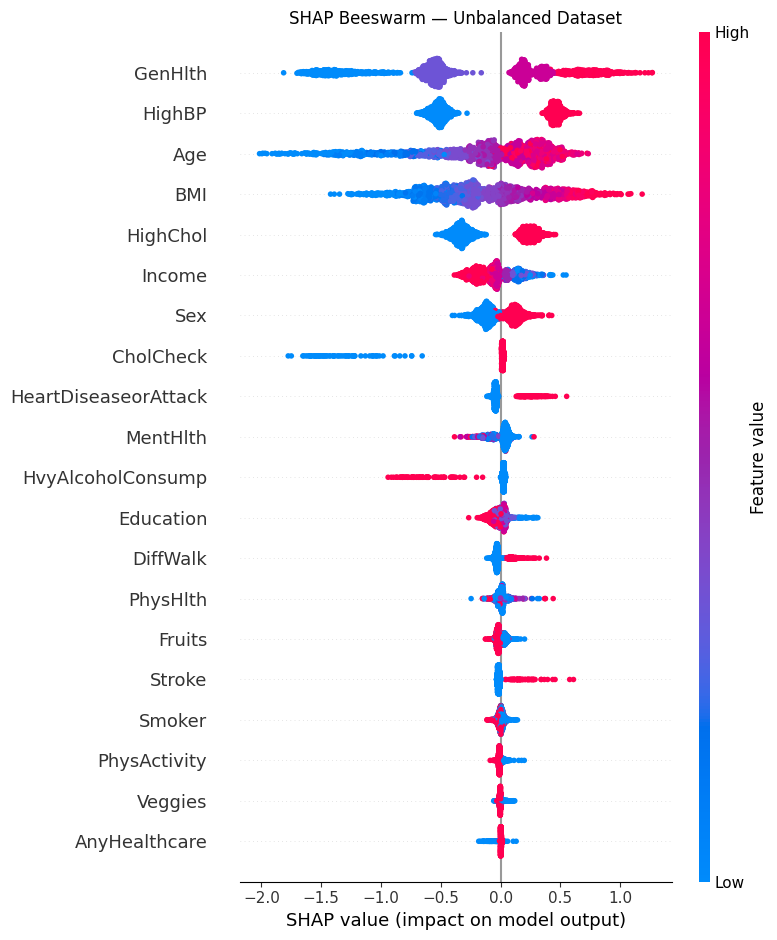

Metric           Balanced   Unbalanced
--------------------------------------
Accuracy           0.7539       0.8656
F1 Score           0.7647       0.2537
AUC-ROC            0.8301       0.8273

Note: Higher accuracy on unbalanced set is misleading — ~86% majority class inflates it. AUC is the fairer comparison.


In [19]:
# ── Section 8: SHAP on Unbalanced Dataset  ──────────────────────

df_unbal = pd.read_csv('./data/diabetes_binary_health_indicators_BRFSS2015.csv')

X_u = df_unbal.drop('Diabetes_binary', axis=1)
y_u = df_unbal['Diabetes_binary']

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_u, y_u, test_size=0.2, random_state=42, stratify=y_u
)

scaler_u = StandardScaler()
X_train_u_scaled = pd.DataFrame(scaler_u.fit_transform(X_train_u), columns=X_u.columns)
X_test_u_scaled = pd.DataFrame(scaler_u.transform(X_test_u), columns=X_u.columns)

xgb_u = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                       random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_u.fit(X_train_u_scaled, y_train_u)

y_pred_u = xgb_u.predict(X_test_u_scaled)
y_prob_u = xgb_u.predict_proba(X_test_u_scaled)[:, 1]

print('=== XGBoost on Unbalanced Dataset ===')
print(f'Accuracy:  {accuracy_score(y_test_u, y_pred_u):.4f}')
print(f'F1 Score:  {f1_score(y_test_u, y_pred_u):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test_u, y_prob_u):.4f}')
print()
print(classification_report(y_test_u, y_pred_u, target_names=['No Diabetes', 'Diabetes']))

# SHAP
explainer_u = shap.TreeExplainer(xgb_u)
X_sample_u = X_test_u_scaled.sample(2000, random_state=42)
shap_values_u = explainer_u.shap_values(X_sample_u)

shap_importance_u = pd.Series(
    np.abs(shap_values_u).mean(axis=0), index=X_sample_u.columns
).sort_values(ascending=False)

# Balanced vs Unbalanced side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
shap_importance.head(10).sort_values().plot(kind='barh', ax=axes[0], color='#E76F51')
axes[0].set_title('SHAP Importance — Balanced Dataset')
axes[0].set_xlabel('Mean |SHAP Value|')
shap_importance_u.head(10).sort_values().plot(kind='barh', ax=axes[1], color='#4CAF50')
axes[1].set_title('SHAP Importance — Unbalanced Dataset')
axes[1].set_xlabel('Mean |SHAP Value|')
plt.suptitle('SHAP Feature Importance: Balanced vs Unbalanced', fontsize=13)
plt.tight_layout()
plt.savefig('shap_balanced_vs_unbalanced.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm unbalanced
plt.figure()
shap.summary_plot(shap_values_u, X_sample_u, show=False)
plt.title('SHAP Beeswarm — Unbalanced Dataset')
plt.tight_layout()
plt.savefig('shap_beeswarm_unbalanced.png', dpi=150, bbox_inches='tight')
plt.show()

# Metric comparison
print(f'{"Metric":<12} {"Balanced":>12} {"Unbalanced":>12}')
print('-' * 38)
print(f'{"Accuracy":<12} {accuracy_score(y_test, xgb.predict(X_test_scaled)):>12.4f} {accuracy_score(y_test_u, y_pred_u):>12.4f}')
print(f'{"F1 Score":<12} {f1_score(y_test, xgb.predict(X_test_scaled)):>12.4f} {f1_score(y_test_u, y_pred_u):>12.4f}')
print(f'{"AUC-ROC":<12} {roc_auc_score(y_test, xgb.predict_proba(X_test_scaled)[:,1]):>12.4f} {roc_auc_score(y_test_u, y_prob_u):>12.4f}')
print()
print('Note: Higher accuracy on unbalanced set is misleading — ~86% majority class inflates it. AUC is the fairer comparison.')

In [20]:
!pip install imbalanced-learn

Before SMOTE: {0.0: np.int64(174667), 1.0: np.int64(28277)}
After SMOTE:  {0.0: np.int64(174667), 1.0: np.int64(174667)}

=== XGBoost on SMOTE Dataset ===
Accuracy:  0.8642
F1 Score:  0.2988
AUC-ROC:   0.8229

              precision    recall  f1-score   support

 No Diabetes       0.88      0.97      0.92     43667
    Diabetes       0.53      0.21      0.30      7069

    accuracy                           0.86     50736
   macro avg       0.71      0.59      0.61     50736
weighted avg       0.83      0.86      0.84     50736



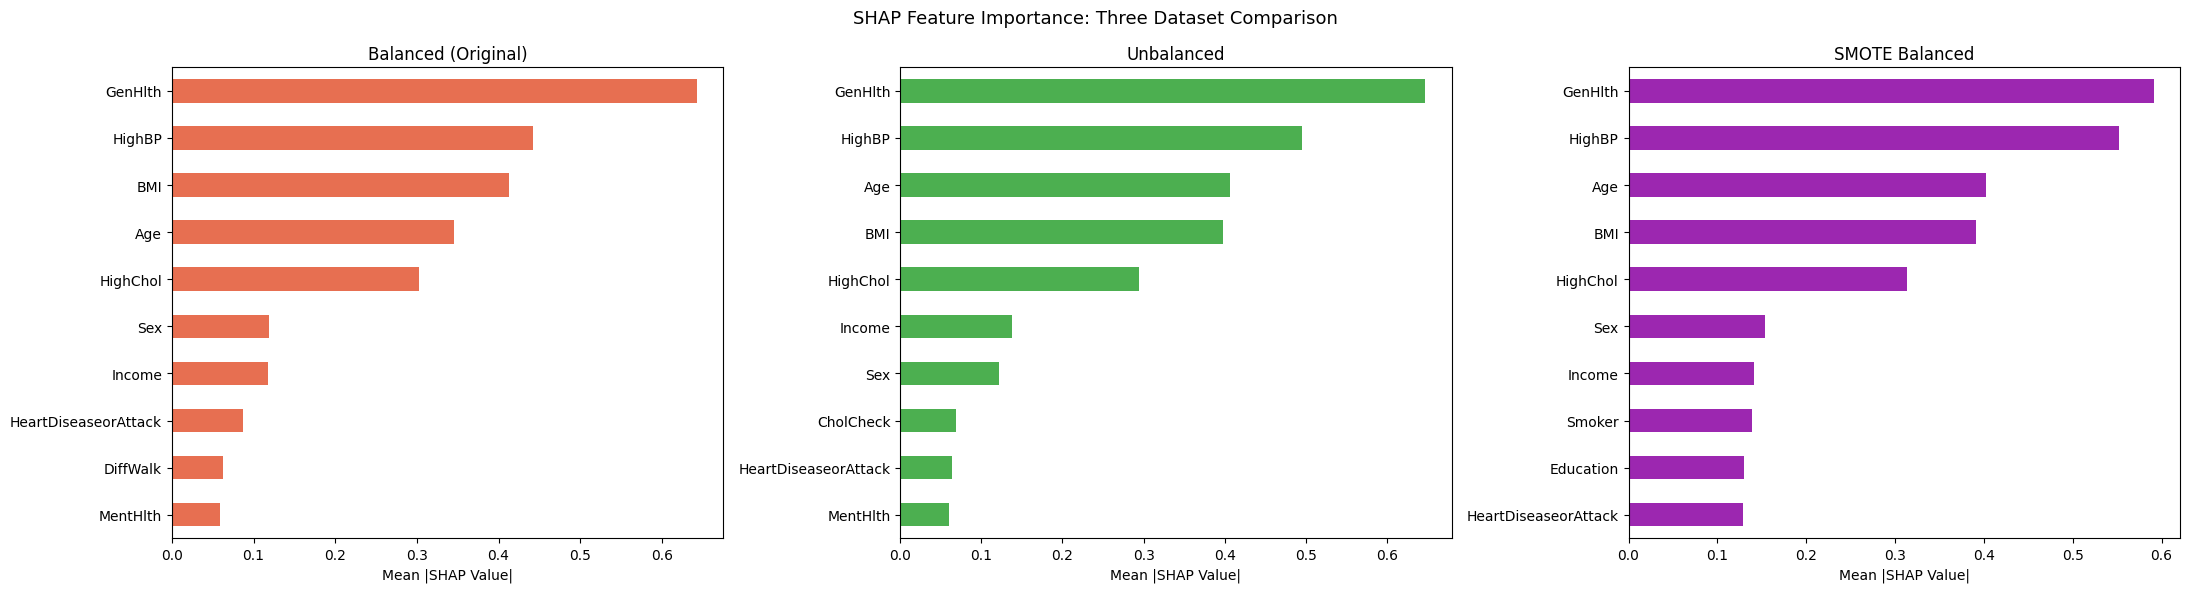

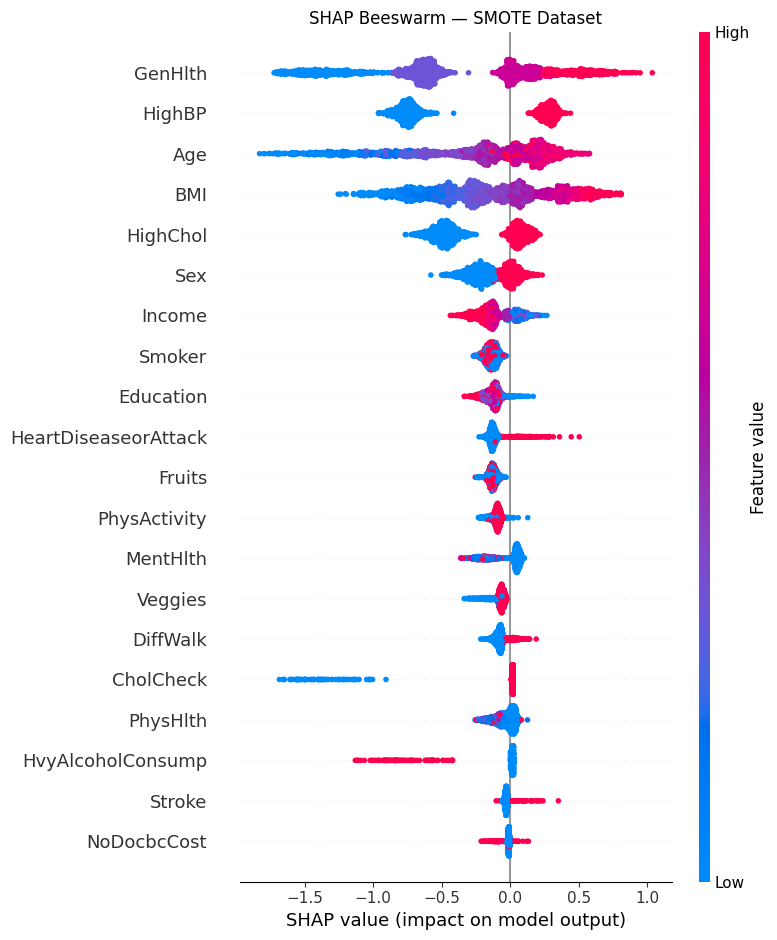


Metric           Balanced   Unbalanced        SMOTE
--------------------------------------------------
Accuracy           0.7539       0.8656       0.8642
F1 Score           0.7647       0.2537       0.2988
AUC-ROC            0.8301       0.8273       0.8229


In [21]:
# ── Section 9: SMOTE Balanced Dataset + SHAP ────────────────────────────────

from imblearn.over_sampling import SMOTE
!pip install imbalanced-learn --quiet

# Use the unbalanced dataset
X_smote = df_unbal.drop('Diabetes_binary', axis=1)
y_smote = df_unbal['Diabetes_binary']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

# Apply SMOTE only on train set
sm = SMOTE(random_state=42)
X_train_s_res, y_train_s_res = sm.fit_resample(X_train_s, y_train_s)

print('Before SMOTE:', dict(pd.Series(y_train_s).value_counts()))
print('After SMOTE: ', dict(pd.Series(y_train_s_res).value_counts()))

scaler_s = StandardScaler()
X_train_s_scaled = pd.DataFrame(scaler_s.fit_transform(X_train_s_res), columns=X_smote.columns)
X_test_s_scaled = pd.DataFrame(scaler_s.transform(X_test_s), columns=X_smote.columns)

xgb_s = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                       random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_s.fit(X_train_s_scaled, y_train_s_res)

y_pred_s = xgb_s.predict(X_test_s_scaled)
y_prob_s = xgb_s.predict_proba(X_test_s_scaled)[:, 1]

print('\n=== XGBoost on SMOTE Dataset ===')
print(f'Accuracy:  {accuracy_score(y_test_s, y_pred_s):.4f}')
print(f'F1 Score:  {f1_score(y_test_s, y_pred_s):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test_s, y_prob_s):.4f}')
print()
print(classification_report(y_test_s, y_pred_s, target_names=['No Diabetes', 'Diabetes']))

# SHAP
explainer_s = shap.TreeExplainer(xgb_s)
X_sample_s = X_test_s_scaled.sample(2000, random_state=42)
shap_values_s = explainer_s.shap_values(X_sample_s)

shap_importance_s = pd.Series(
    np.abs(shap_values_s).mean(axis=0), index=X_sample_s.columns
).sort_values(ascending=False)

# Three-way comparison plot
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
shap_importance.head(10).sort_values().plot(kind='barh', ax=axes[0], color='#E76F51')
axes[0].set_title('Balanced (Original)')
axes[0].set_xlabel('Mean |SHAP Value|')

shap_importance_u.head(10).sort_values().plot(kind='barh', ax=axes[1], color='#4CAF50')
axes[1].set_title('Unbalanced')
axes[1].set_xlabel('Mean |SHAP Value|')

shap_importance_s.head(10).sort_values().plot(kind='barh', ax=axes[2], color='#9C27B0')
axes[2].set_title('SMOTE Balanced')
axes[2].set_xlabel('Mean |SHAP Value|')

plt.suptitle('SHAP Feature Importance: Three Dataset Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('shap_three_way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm
plt.figure()
shap.summary_plot(shap_values_s, X_sample_s, show=False)
plt.title('SHAP Beeswarm — SMOTE Dataset')
plt.tight_layout()
plt.savefig('shap_beeswarm_smote.png', dpi=150, bbox_inches='tight')
plt.show()

# Full three-way metric comparison
print(f'\n{"Metric":<12} {"Balanced":>12} {"Unbalanced":>12} {"SMOTE":>12}')
print('-' * 50)
print(f'{"Accuracy":<12} {accuracy_score(y_test, xgb.predict(X_test_scaled)):>12.4f} {accuracy_score(y_test_u, y_pred_u):>12.4f} {accuracy_score(y_test_s, y_pred_s):>12.4f}')
print(f'{"F1 Score":<12} {f1_score(y_test, xgb.predict(X_test_scaled)):>12.4f} {f1_score(y_test_u, y_pred_u):>12.4f} {f1_score(y_test_s, y_pred_s):>12.4f}')
print(f'{"AUC-ROC":<12} {roc_auc_score(y_test, xgb.predict_proba(X_test_scaled)[:,1]):>12.4f} {roc_auc_score(y_test_u, y_prob_u):>12.4f} {roc_auc_score(y_test_s, y_prob_s):>12.4f}')